In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Example Scores

scores = np.array([2.5, 1.2, 0.3])

# Softmax Function

exp_scores = np.exp(scores)

softmax = exp_scores / np.sum(exp_scores)

print("Raw Scores :", scores)

print("Softmax Probabilities :", softmax)

print("Sum of Probabilities :", np.sum(softmax))

Raw Scores : [2.5 1.2 0.3]
Softmax Probabilities : [0.72289072 0.1970107  0.08009858]
Sum of Probabilities : 1.0


In [3]:
df = pd.read_csv("zoo.csv")

class_df = pd.read_csv("class.csv")

In [4]:
print("First Five Records")

print(df.head())

print("\nDataset Information")

print(df.info())

print("\nStatistical Summary")

print(df.describe())

First Five Records
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2

In [5]:
print(df.isnull().sum())

animal_name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
class_type     0
dtype: int64


In [6]:
df = df.drop("animal_name", axis=1)

print(df.head())

   hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  backbone  \
0     1         0     0     1         0        0         1        1         1   
1     1         0     0     1         0        0         0        1         1   
2     0         0     1     0         0        1         1        1         1   
3     1         0     0     1         0        0         1        1         1   
4     1         0     0     1         0        0         1        1         1   

   breathes  venomous  fins  legs  tail  domestic  catsize  class_type  
0         1         0     0     4     0         0        1           1  
1         1         0     0     4     1         0        1           1  
2         0         0     1     0     1         0        0           4  
3         1         0     0     4     0         0        1           1  
4         1         0     0     4     1         0        1           1  


In [7]:
df["class_type"] = df["class_type"] - 1

print(df["class_type"].unique())

[0 3 1 6 5 4 2]


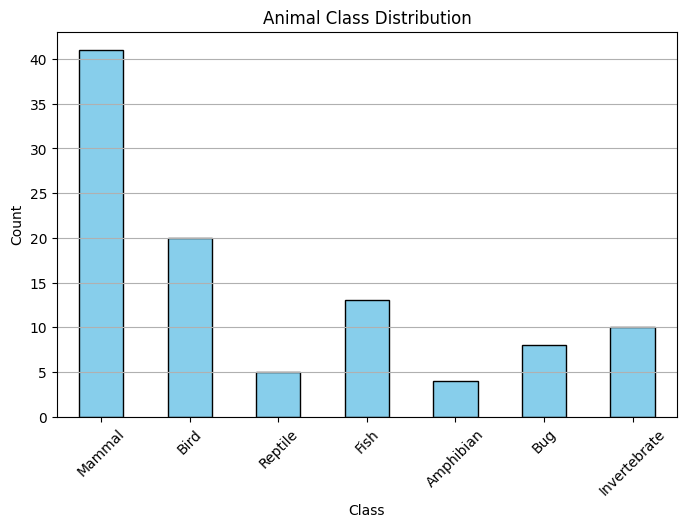

In [8]:
plt.figure(figsize=(8,5))

df["class_type"].value_counts().sort_index().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Animal Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.xticks(
    range(7),
    [
        "Mammal",
        "Bird",
        "Reptile",
        "Fish",
        "Amphibian",
        "Bug",
        "Invertebrate"
    ],
    rotation=45
)

plt.grid(axis='y')

plt.show()

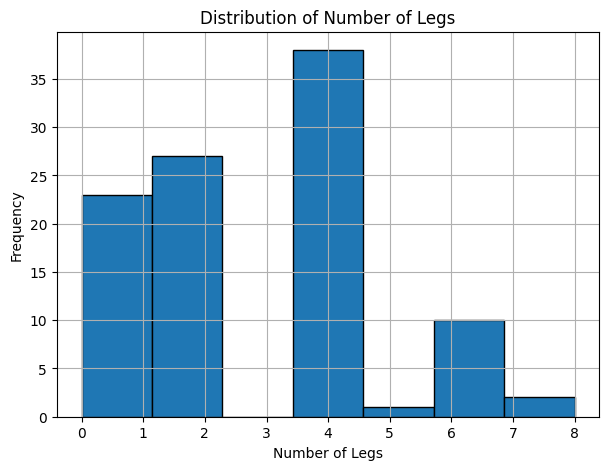

In [9]:
plt.figure(figsize=(7,5))

plt.hist(
    df["legs"],
    bins=7,
    edgecolor="black"
)

plt.title("Distribution of Number of Legs")

plt.xlabel("Number of Legs")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [10]:
# Feature and Target Split

X = df.drop("class_type", axis=1)

y = df["class_type"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (101, 16)
Target Shape : (101,)


In [11]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 80
Testing Samples : 21


In [12]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [13]:
# Build ANN Model

model = Sequential([

    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    BatchNormalization(),

    Dropout(0.30),

    Dense(32, activation='relu'),

    BatchNormalization(),

    Dropout(0.30),

    Dense(7, activation='softmax')

])

model.summary()

C:\Users\shrad\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,783 (14.78 KB)

 Trainable params: 3,591 (14.03 KB)

 Non-trainable params: 192 (768.00 B)

In [14]:
# Compile Model

model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [15]:
# Early Stopping

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

In [16]:
# Train Model

history = model.fit(

    X_train,

    y_train,

    epochs=100,

    batch_size=16,

    validation_split=0.20,

    callbacks=[early_stop]

)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.2344 - loss: 2.9554 - val_accuracy: 0.1875 - val_loss: 1.8870
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2188 - loss: 2.4471 - val_accuracy: 0.2500 - val_loss: 1.8154
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2812 - loss: 2.1841 - val_accuracy: 0.4375 - val_loss: 1.7408
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3594 - loss: 1.8452 - val_accuracy: 0.5000 - val_loss: 1.6668
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4062 - loss: 1.5556 - val_accuracy: 0.5000 - val_loss: 1.5948
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 1.5671 - val_accuracy: 0.6250 - val_loss: 1.5237
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5625 - loss: 1.4241 - val_accuracy: 0.6250 - val_loss: 1.4519
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6250 - loss: 1.1858 - val_accuracy: 0.6250 - val_loss:

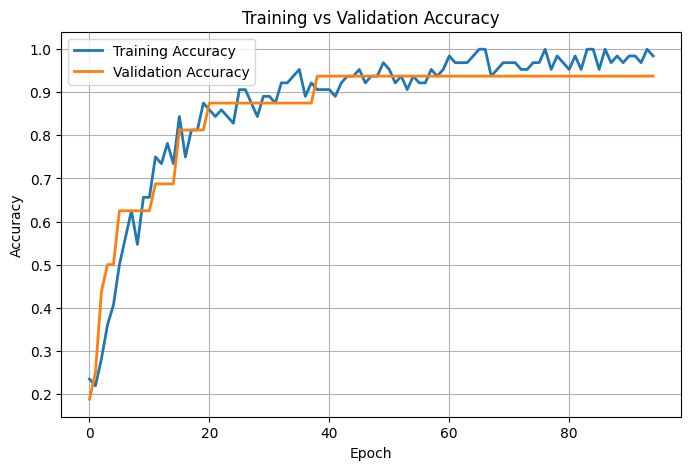

In [17]:
# Training vs Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy',
         linewidth=2)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

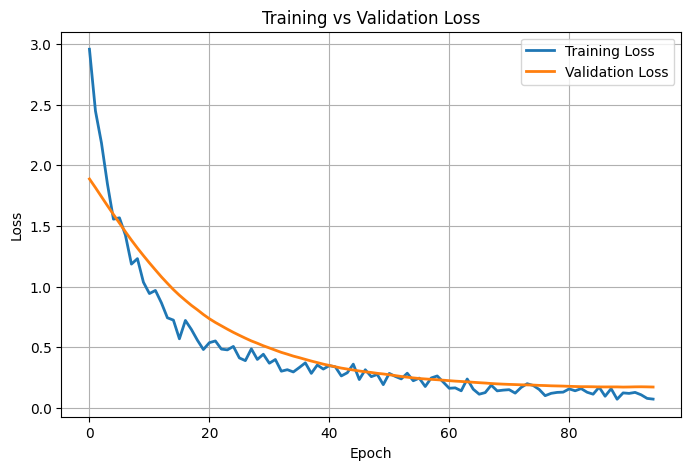

In [18]:
# Training vs Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
# Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

print(f"\nModel Accuracy : {accuracy*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 1.0000 - loss: 0.0917
Test Loss : 0.09169205278158188
Test Accuracy : 1.0

Model Accuracy : 100.00%


In [20]:
# Predict Animal Classes

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print("First 10 Predictions")

print(y_pred[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
First 10 Predictions
[4 1 3 1 0 0 3 5 0 3]


In [21]:
# Accuracy Score

acc = accuracy_score(y_test, y_pred)

print("Accuracy Score :", acc)

print(f"Accuracy Percentage : {acc*100:.2f}%")

Accuracy Score : 1.0
Accuracy Percentage : 100.00%


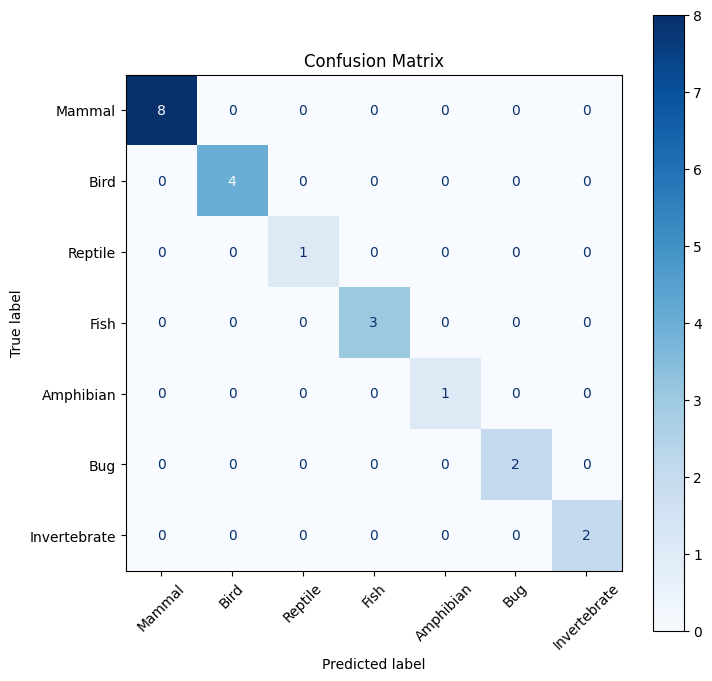

In [22]:
# Class Labels

class_names = [

    "Mammal",

    "Bird",

    "Reptile",

    "Fish",

    "Amphibian",

    "Bug",

    "Invertebrate"

]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")

plt.xticks(rotation=45)

plt.show()

In [23]:
# Classification Report

print("Classification Report\n")

print(classification_report(

    y_test,

    y_pred,

    target_names=class_names

))

Classification Report

              precision    recall  f1-score   support

      Mammal       1.00      1.00      1.00         8
        Bird       1.00      1.00      1.00         4
     Reptile       1.00      1.00      1.00         1
        Fish       1.00      1.00      1.00         3
   Amphibian       1.00      1.00      1.00         1
         Bug       1.00      1.00      1.00         2
Invertebrate       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [24]:
# Actual vs Predicted

comparison = pd.DataFrame({

    "Actual Class": y_test.values,

    "Predicted Class": y_pred

})

print(comparison.head(20))

    Actual Class  Predicted Class
0              4                4
1              1                1
2              3                3
3              1                1
4              0                0
5              0                0
6              3                3
7              5                5
8              0                0
9              3                3
10             6                6
11             0                0
12             0                0
13             6                6
14             0                0
15             1                1
16             2                2
17             5                5
18             0                0
19             0                0


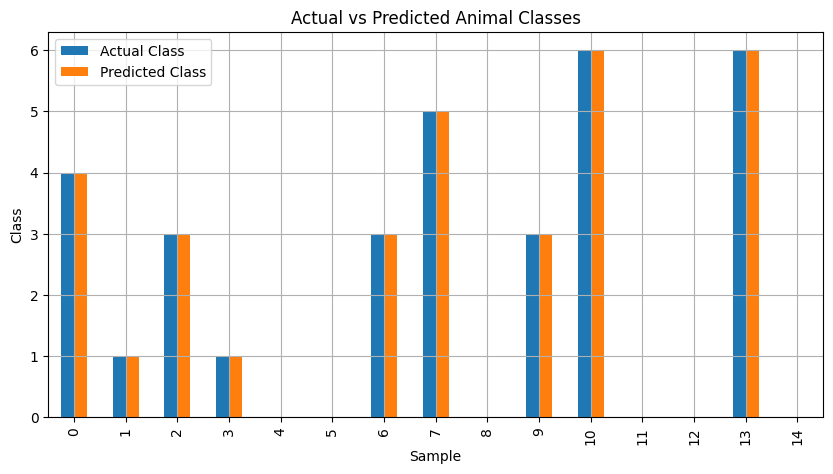

In [25]:
# Comparison Graph

comparison.head(15).plot(

    kind="bar",

    figsize=(10,5)

)

plt.title("Actual vs Predicted Animal Classes")

plt.xlabel("Sample")

plt.ylabel("Class")

plt.grid(True)

plt.show()